In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
import sys
if not sys.warnoptions:
    warnings.simplefilter("ignore")

In [2]:
df = pd.read_csv('bankloan.csv')

In [3]:
df.head

<bound method NDFrame.head of         ID  Age  Experience  Income  ZIP.Code  Family  CCAvg  Education  \
0        1   25           1      49     91107       4    1.6          1   
1        2   45          19      34     90089       3    1.5          1   
2        3   39          15      11     94720       1    1.0          1   
3        4   35           9     100     94112       1    2.7          2   
4        5   35           8      45     91330       4    1.0          2   
...    ...  ...         ...     ...       ...     ...    ...        ...   
4995  4996   29           3      40     92697       1    1.9          3   
4996  4997   30           4      15     92037       4    0.4          1   
4997  4998   63          39      24     93023       2    0.3          3   
4998  4999   65          40      49     90034       3    0.5          2   
4999  5000   28           4      83     92612       3    0.8          1   

      Mortgage  Personal.Loan  Securities.Account  CD.Account  Online

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIP.Code            5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal.Loan       5000 non-null   int64  
 10  Securities.Account  5000 non-null   int64  
 11  CD.Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


In [5]:
df.isnull().sum()

ID                    0
Age                   0
Experience            0
Income                0
ZIP.Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal.Loan         0
Securities.Account    0
CD.Account            0
Online                0
CreditCard            0
dtype: int64

In [6]:
df = df.drop(['ID','ZIP.Code'],axis = 1)
df[df['Experience']<0]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
89,25,-1,113,4,2.30,3,0,0,0,0,0,1
226,24,-1,39,2,1.70,2,0,0,0,0,0,0
315,24,-2,51,3,0.30,3,0,0,0,0,1,0
451,28,-2,48,2,1.75,3,89,0,0,0,1,0
524,24,-1,75,4,0.20,1,0,0,0,0,1,0
536,25,-1,43,3,2.40,2,176,0,0,0,1,0
540,25,-1,109,4,2.30,3,314,0,0,0,1,0
576,25,-1,48,3,0.30,3,0,0,0,0,0,1
583,24,-1,38,2,1.70,2,0,0,0,0,1,0
597,24,-2,125,2,7.20,1,0,0,1,0,0,1


In [7]:

df['Experience'] = abs(df['Experience'])
#rechecking if there are any negative values present
df[df['Experience']<0]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard


In [8]:
df[['Age','Experience','Income','CCAvg','Mortgage']].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.134600,11.415189,0.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0


In [9]:
df.columns

Index(['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Education',
       'Mortgage', 'Personal.Loan', 'Securities.Account', 'CD.Account',
       'Online', 'CreditCard'],
      dtype='object')

In [10]:

df.duplicated().sum()

13

In [11]:
df.drop_duplicates()

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard
0,25,1,49,4,1.6,1,0,0,1,0,0,0
1,45,19,34,3,1.5,1,0,0,1,0,0,0
2,39,15,11,1,1.0,1,0,0,0,0,0,0
3,35,9,100,1,2.7,2,0,0,0,0,0,0
4,35,8,45,4,1.0,2,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4995,29,3,40,1,1.9,3,0,0,0,0,1,0
4996,30,4,15,4,0.4,1,85,0,0,0,1,0
4997,63,39,24,2,0.3,3,0,0,0,0,0,0
4998,65,40,49,3,0.5,2,0,0,0,0,1,0


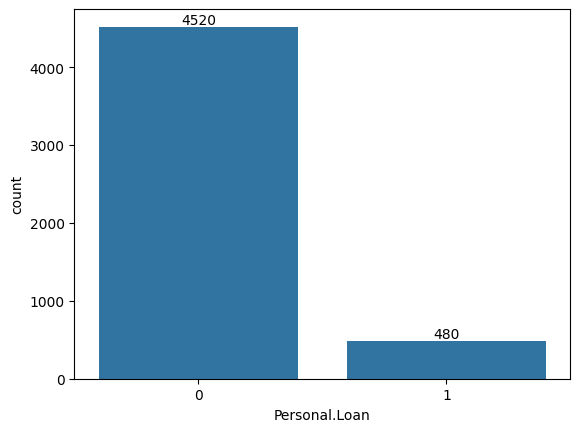

In [12]:
ax= sns.countplot(data = df, x = 'Personal.Loan')
for i in ax.containers:
    ax.bar_label(i,)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


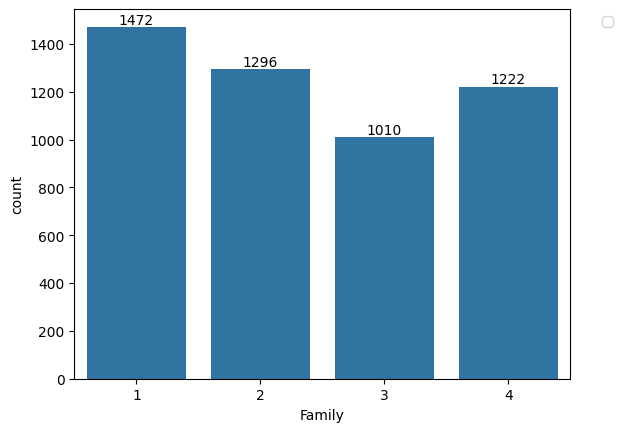

In [13]:
ax=sns.countplot(data=df,x="Family")
for i in ax.containers:
    ax.bar_label(i,)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

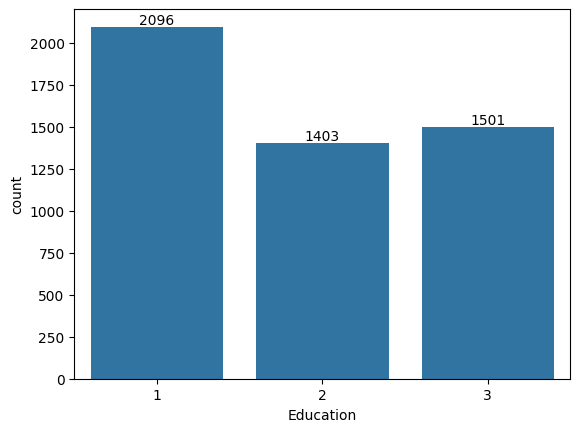

In [14]:
ax=sns.countplot(data = df, x ='Education')
for i in ax.containers:
    ax.bar_label(i,)

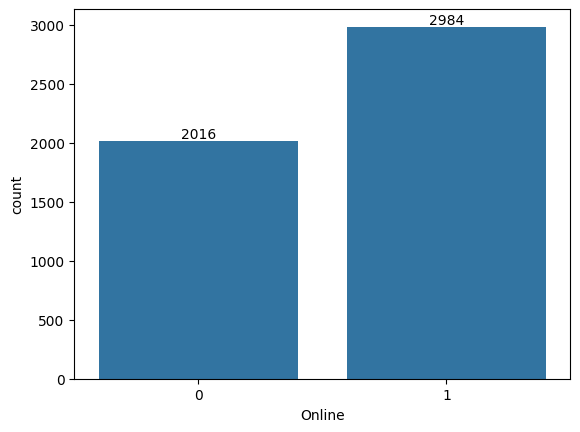

In [15]:
ax=sns.countplot(data=df,x='Online')
for i in ax.containers:
    ax.bar_label(i,)

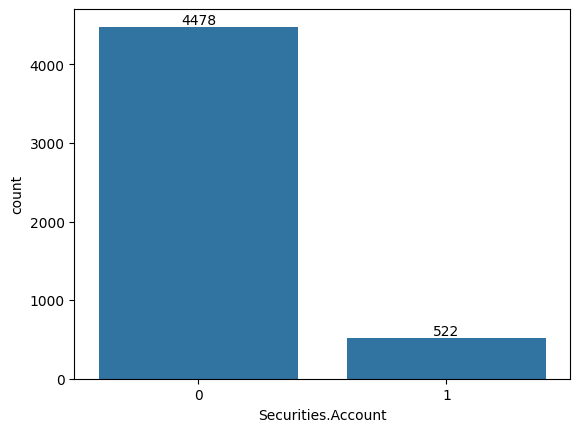

In [16]:
ax = sns.countplot(data=df,x='Securities.Account')
for i in ax.containers:
    ax.bar_label(i,)

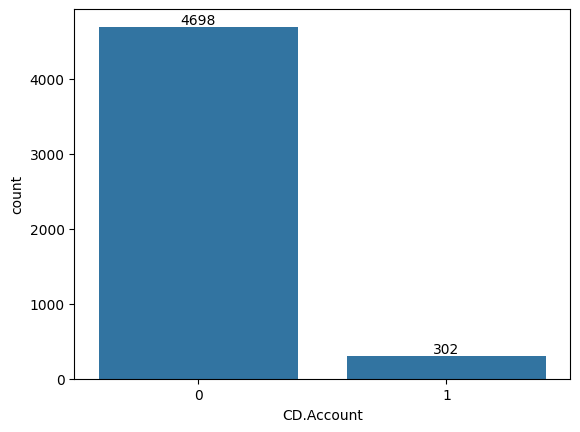

In [17]:
ax = sns.countplot(data=df,x='CD.Account')
for i in ax.containers:
    ax.bar_label(i,)

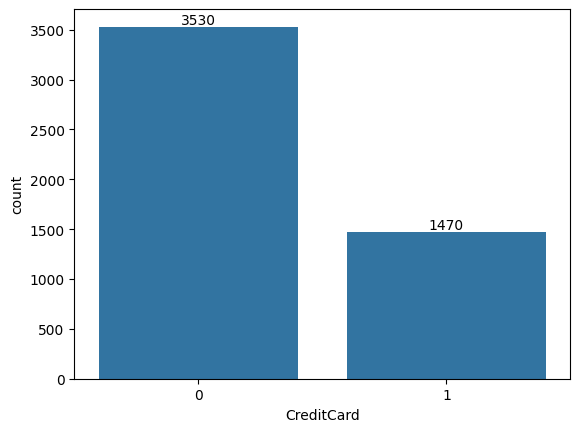

In [18]:
ax = sns.countplot(data=df,x='CreditCard')
for i in ax.containers:
    ax.bar_label(i,)

<Axes: xlabel='Income', ylabel='Count'>

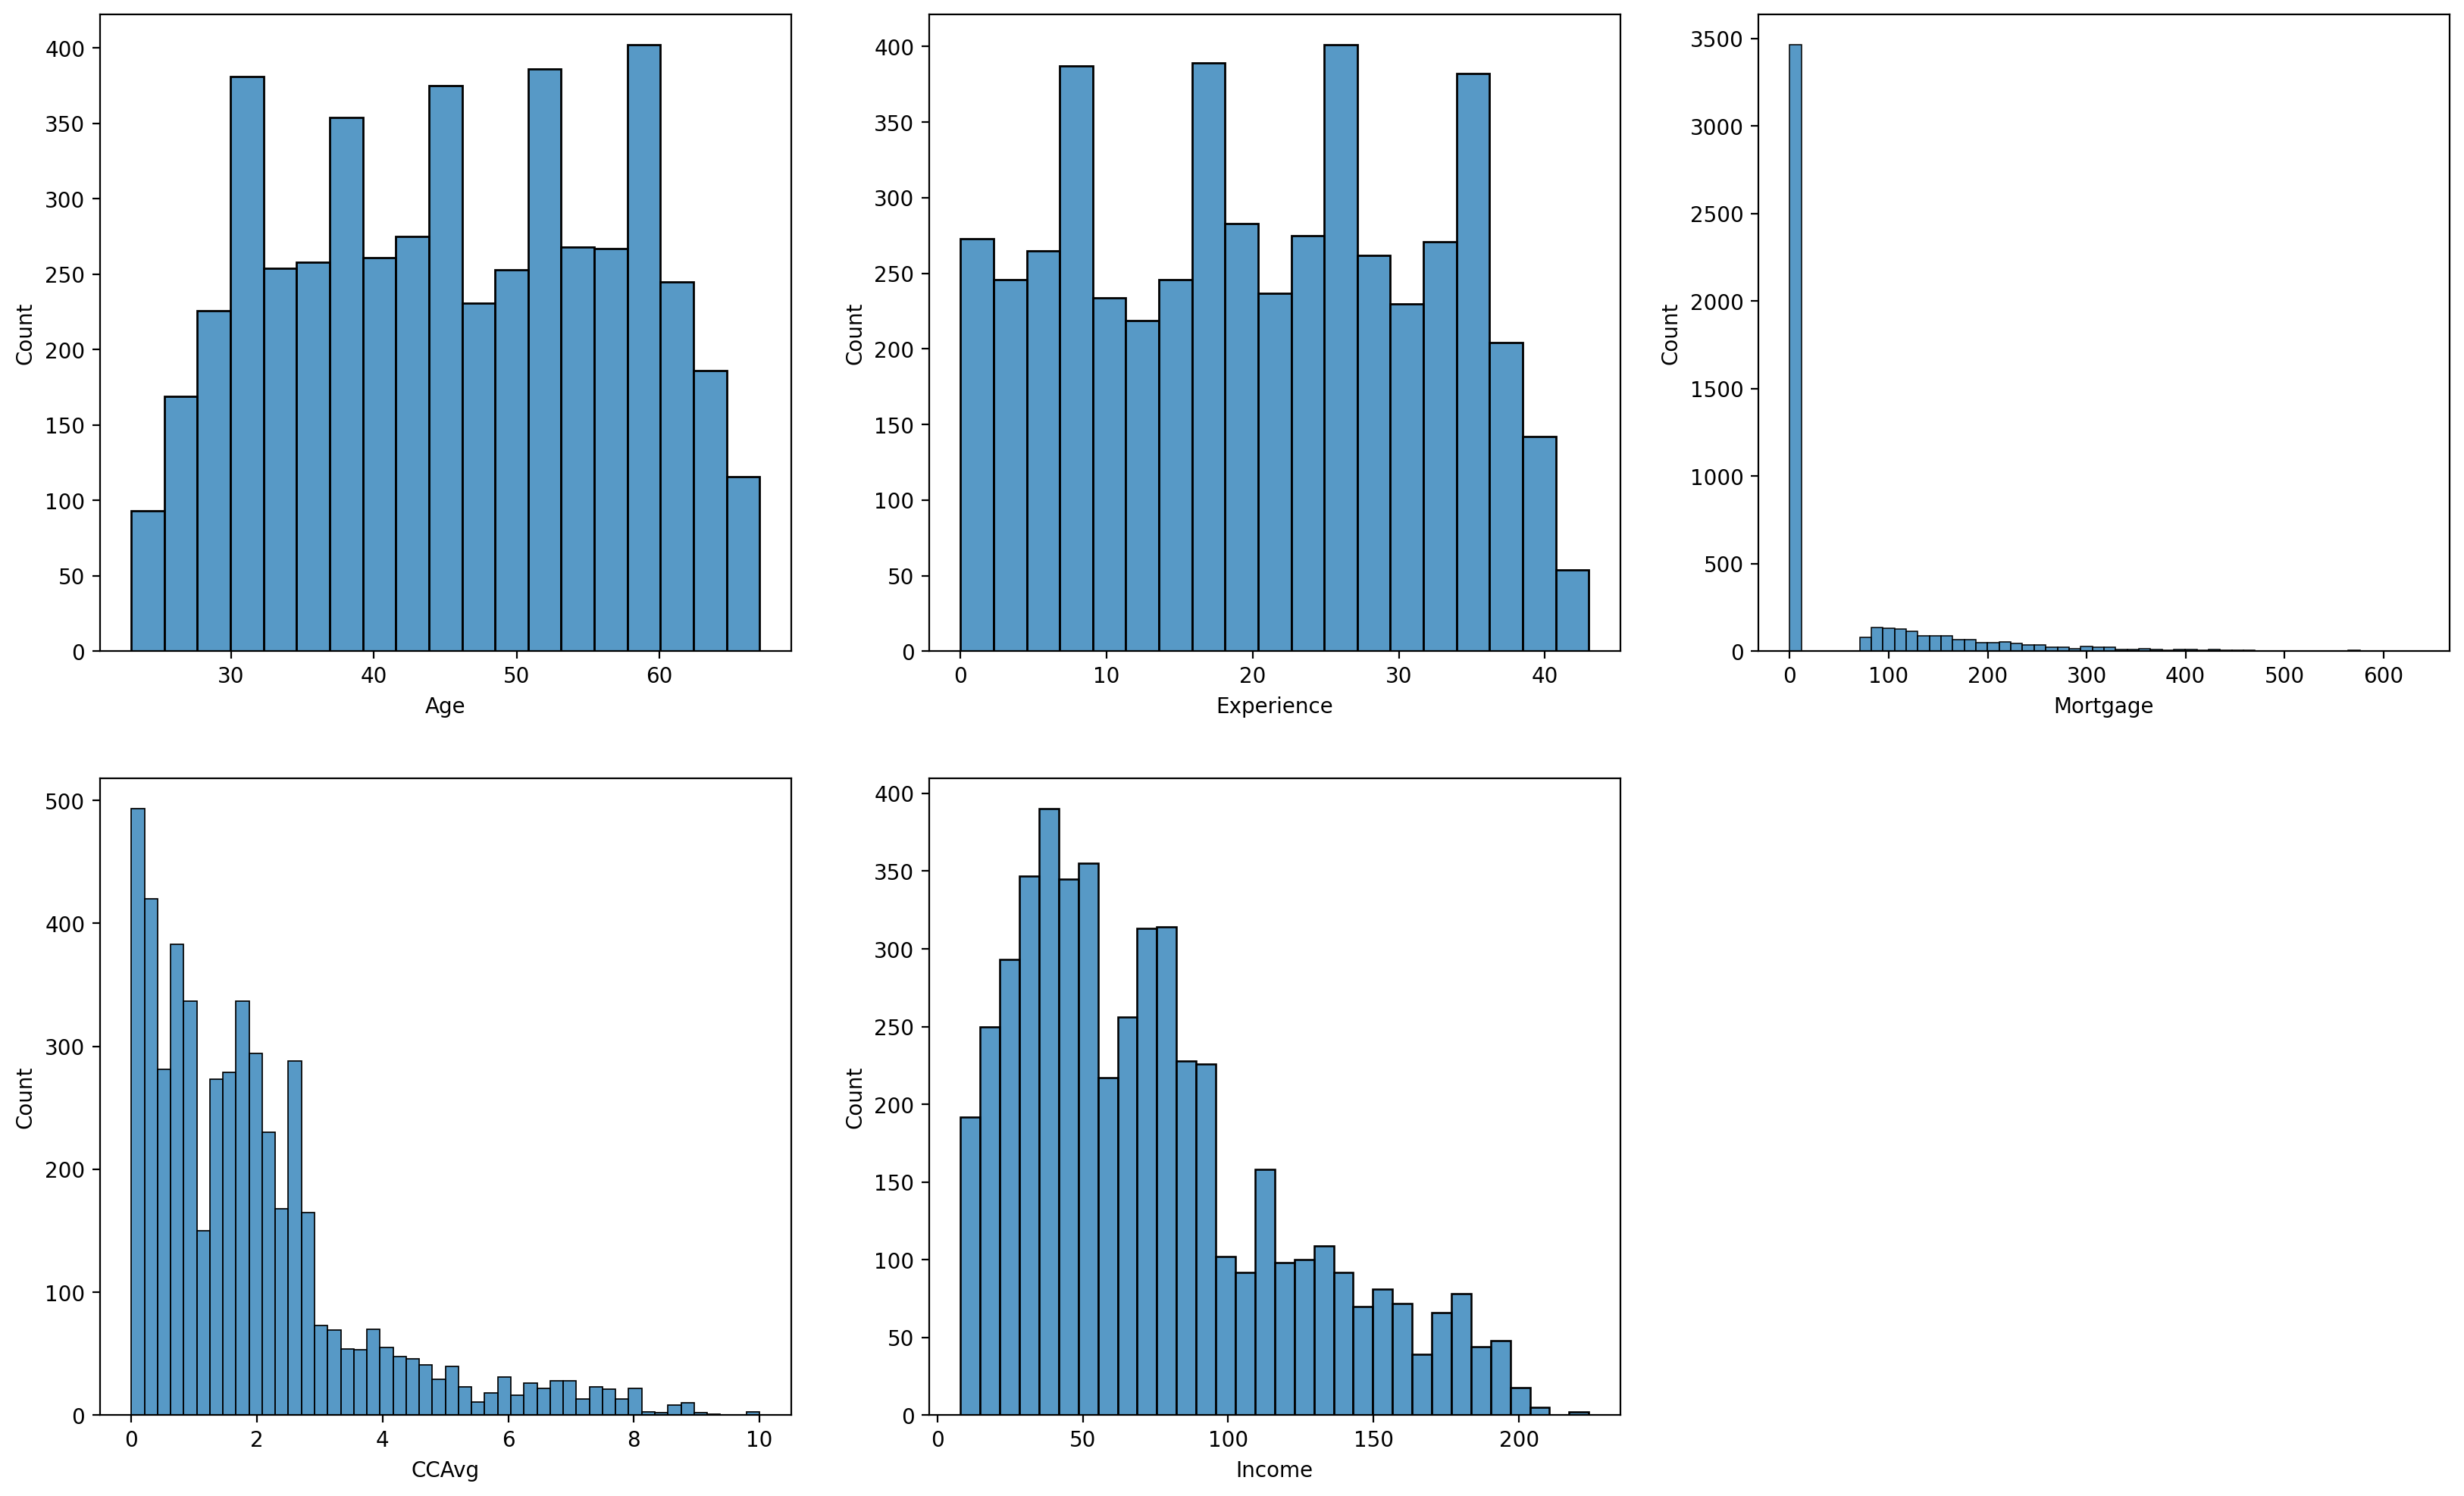

In [19]:
plt.figure(figsize=(20,12),dpi=200)

plt.subplot(2,3,1)
sns.histplot(data=df,x='Age')

plt.subplot(2,3,2)
sns.histplot(data=df,x='Experience')

plt.subplot(2,3,3)
sns.histplot(data=df,x='Mortgage')

plt.subplot(2,3,4)
sns.histplot(data=df,x='CCAvg')

plt.subplot(2,3,5)
sns.histplot(data=df,x='Income')

In [20]:
df_cont = df[['Age','Experience','Mortgage','CCAvg','Income']]
df_cont.skew()

Age          -0.029341
Experience   -0.010038
Mortgage      2.104002
CCAvg         1.598443
Income        0.841339
dtype: float64

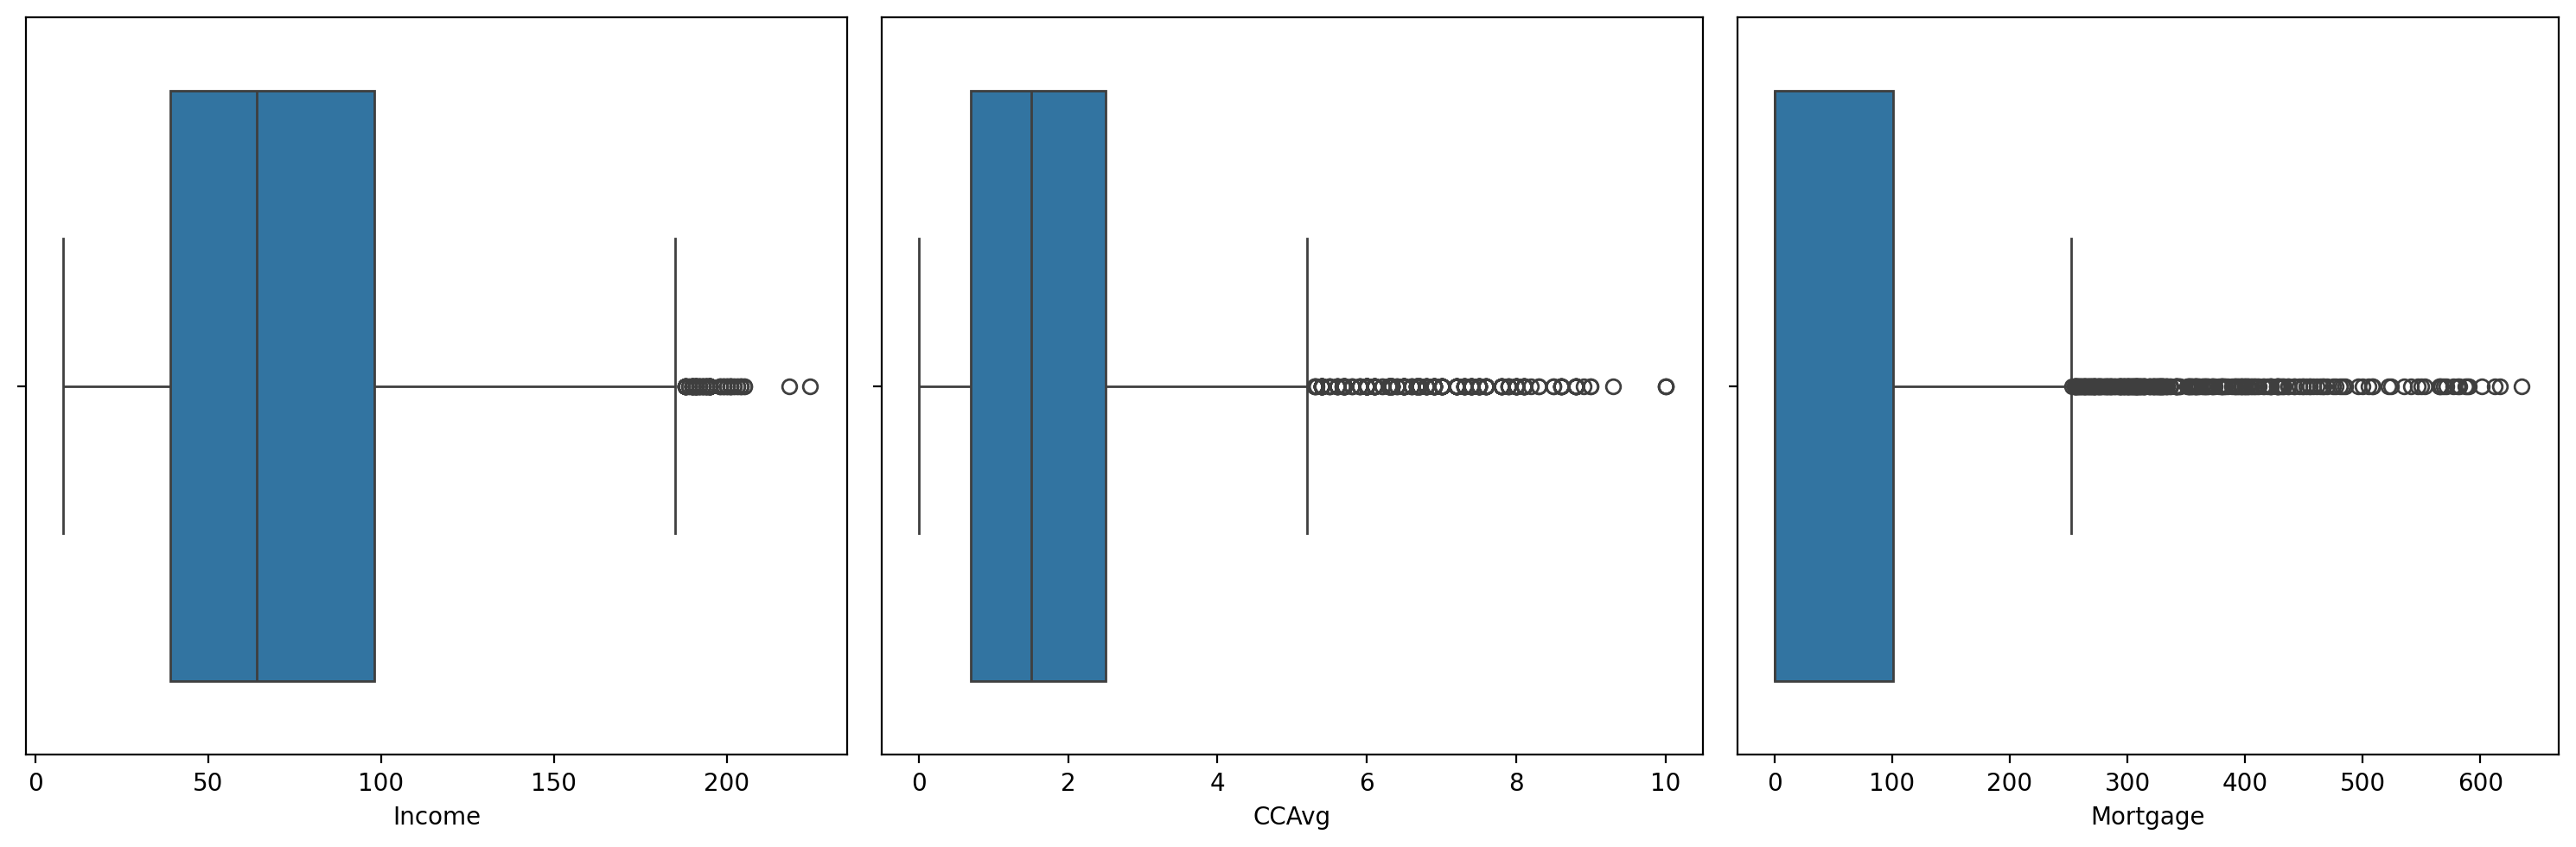

In [21]:
plt.figure(figsize = (15,5),dpi = 200)

plt.subplot(1,3,1)
sns.boxplot(x = 'Income', data = df)

plt.subplot(1,3,2)
sns.boxplot(x ='CCAvg', data = df)

plt.subplot(1,3,3)
sns.boxplot(x ='Mortgage', data = df)

plt.tight_layout()

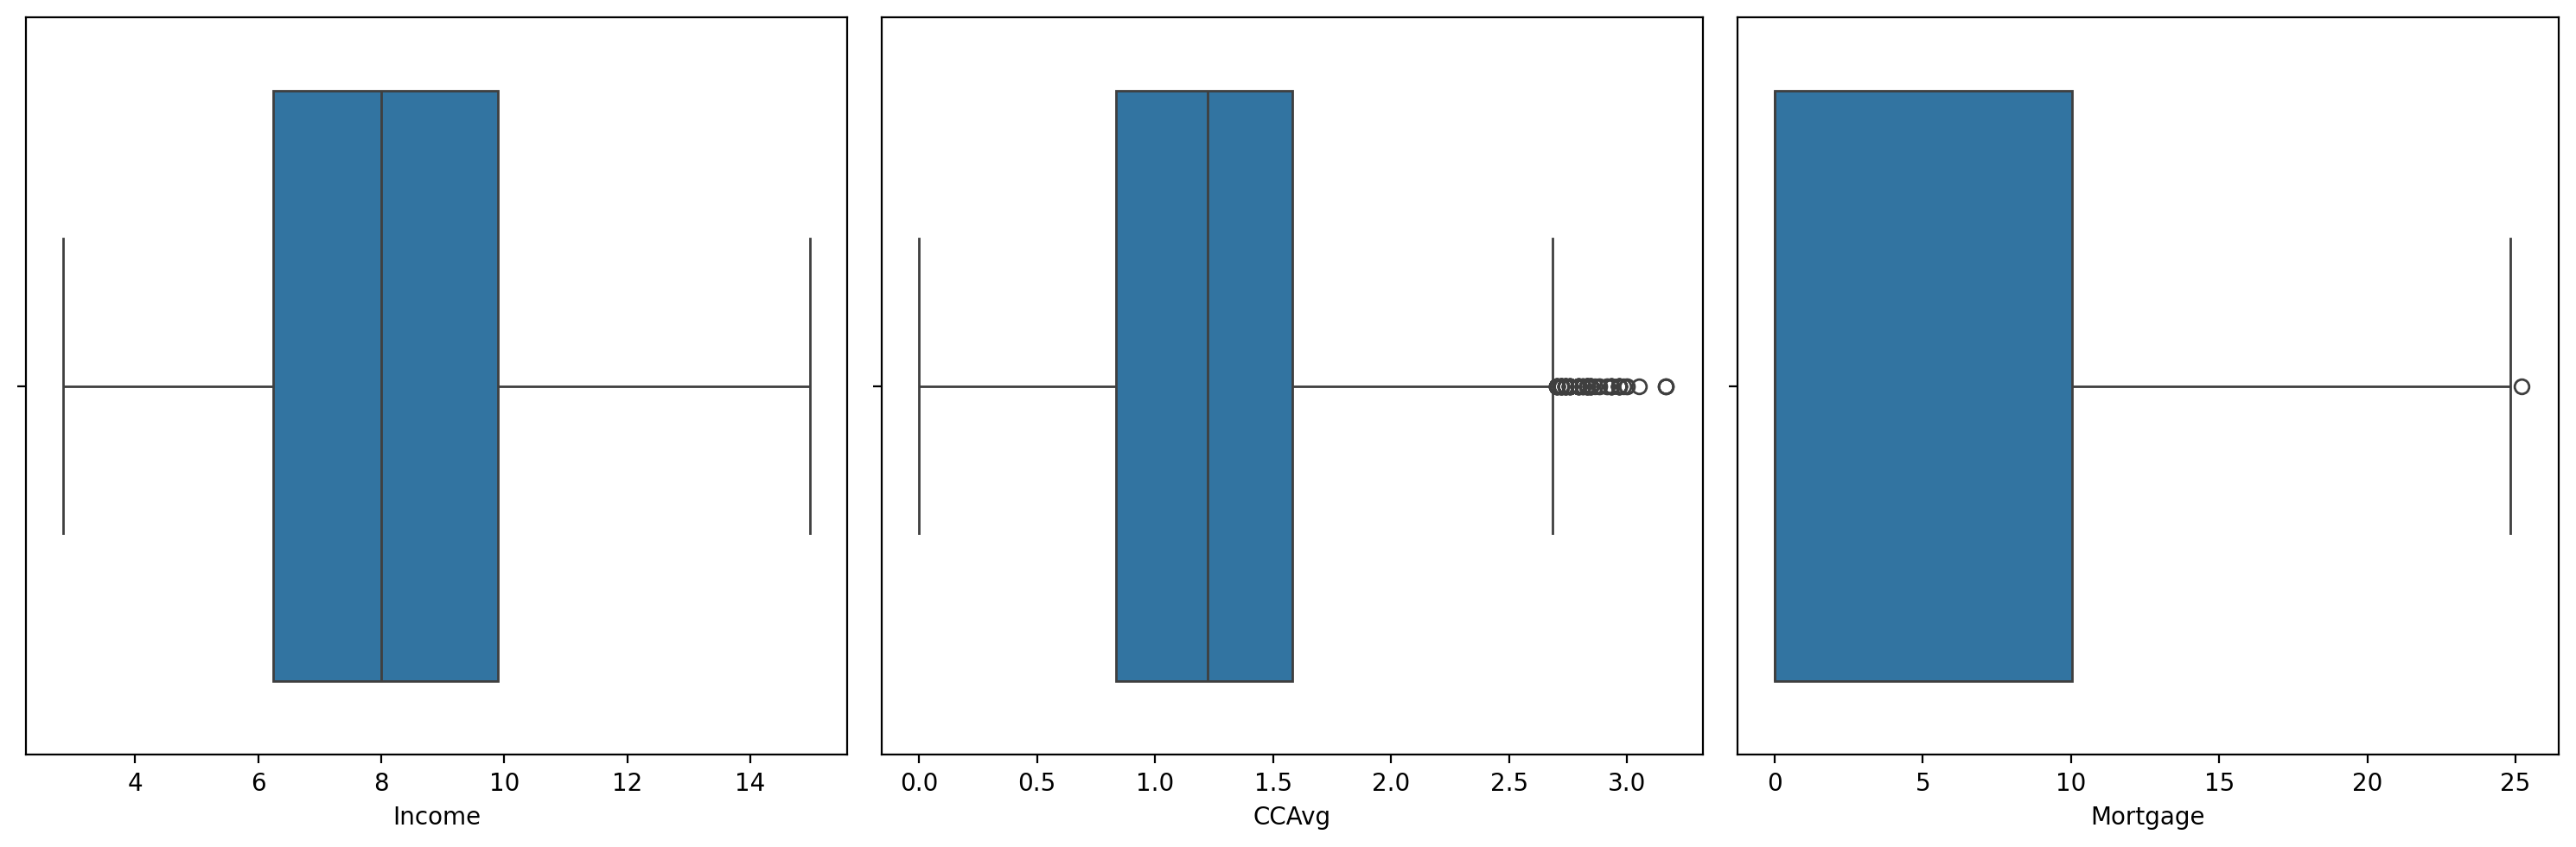

In [22]:

df['Income'] = np.sqrt(df['Income'])
df['CCAvg'] = np.sqrt(df['CCAvg'])
df['Mortgage'] = np.sqrt(df['Mortgage'])
plt.figure(figsize = (15,5),dpi = 200)

plt.subplot(1,3,1)
sns.boxplot(x = 'Income', data = df)

plt.subplot(1,3,2)
sns.boxplot(x ='CCAvg', data = df)

plt.subplot(1,3,3)
sns.boxplot(x ='Mortgage', data = df)

plt.tight_layout()

In [23]:
Q1 = df['CCAvg'].quantile(0.25)
Q3 = df['CCAvg'].quantile(0.75)
IQR = Q3 - Q1
UL = Q3 + 1.5*IQR
LL = Q1 - 1.5*IQR

In [24]:
df.loc[df['CCAvg'] <= LL]

,Age,Experience,Income,Family,CCAvg,Education,Mortgage,Personal.Loan,Securities.Account,CD.Account,Online,CreditCard


In [25]:
df.loc[df['CCAvg'] >= UL,'CCAvg'] = UL

<Axes: xlabel='CCAvg'>

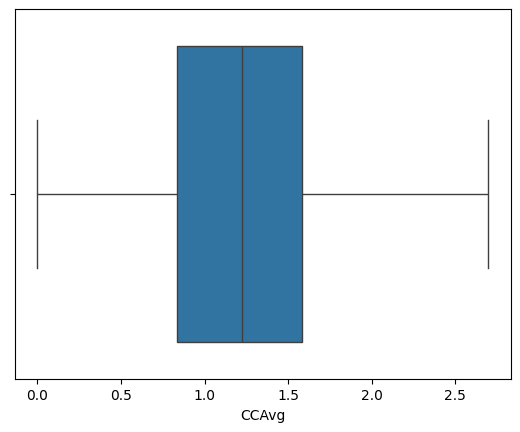

In [26]:
sns.boxplot(x ='CCAvg', data = df)

<Axes: >

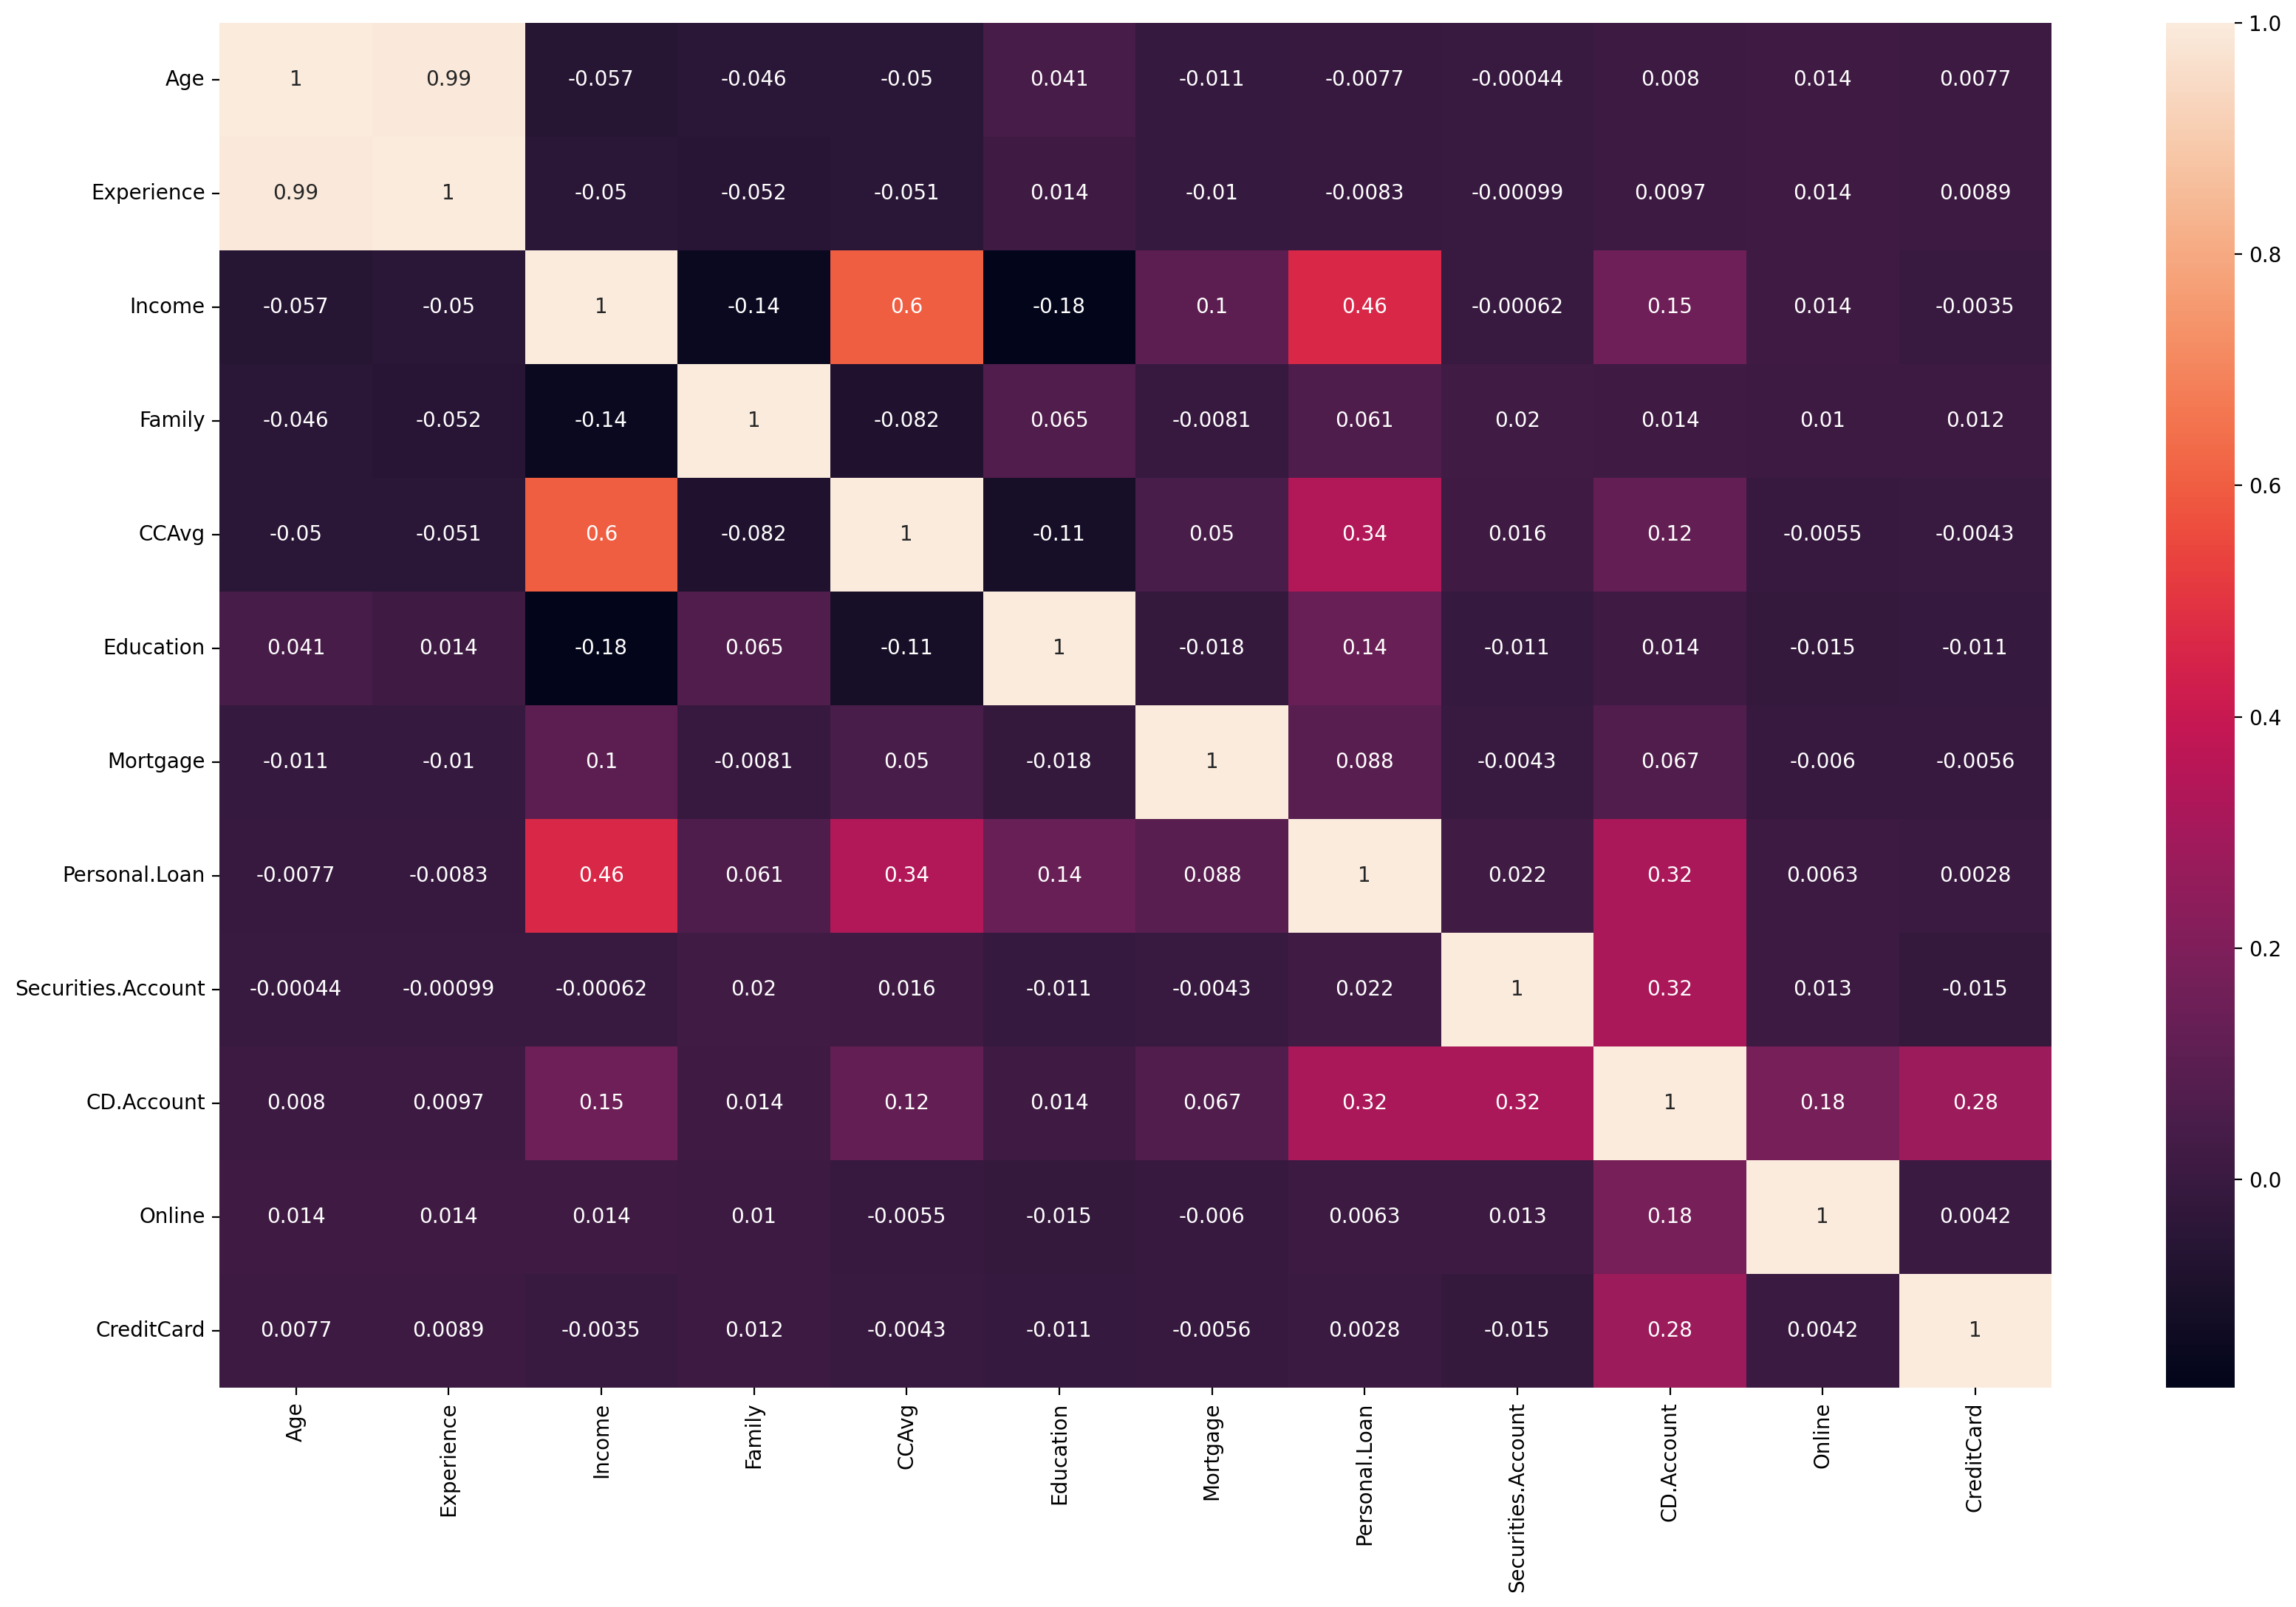

In [27]:
plt.figure(figsize=(20,12),dpi=200)
sns.heatmap(df.corr(),annot=True)

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [29]:
y = df['Personal.Loan']
x = df.drop(['Personal.Loan'],axis=1)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, random_state=101)

In [31]:
from collections import Counter
from imblearn.combine import SMOTETomek

counter = Counter(y_train)
print('Before',counter)
smt = SMOTETomek()
x_train_sm,y_train_sm = smt.fit_resample(X_train,y_train)

counter = Counter(y_train_sm)
print('After',counter)

Before Counter({0: 4063, 1: 437})
After Counter({0: 4059, 1: 4059})


In [32]:
scaler = StandardScaler()

In [33]:
X_train_scaled = scaler.fit_transform(x_train_sm)
X_test_scaled = scaler.transform(X_test)

In [34]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(X_train_scaled,y_train_sm)

LogisticRegression()

In [35]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

knn_model = KNeighborsClassifier(algorithm='auto')
k_values = list(range(1,20))
param_grid = {'n_neighbors':k_values}
knn_classifier = GridSearchCV(knn_model,param_grid,scoring='accuracy',cv=5)

In [36]:
knn_classifier.fit(X_train_scaled,y_train_sm)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19]},
             scoring='accuracy')

In [37]:
knn_classifier.best_params_

{'n_neighbors': 1}

In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
dt_model = DecisionTreeClassifier()
param_dt = {'max_depth':list(range(1,10)),'min_samples_split':list(range(2,10))}
gs_dt_model = GridSearchCV(dt_model,param_dt,cv=5,scoring='accuracy')
gs_dt_model.fit(x_train_sm,y_train_sm)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9],
                         'min_samples_split': [2, 3, 4, 5, 6, 7, 8, 9]},
             scoring='accuracy')

In [39]:
gs_dt_model.best_params_

{'max_depth': 9, 'min_samples_split': 3}

In [40]:
n_estimators = [int(x) for x in np.linspace(start=10,stop=80,num=10)]
max_features = ['log2','sqrt',None]
max_depth = [2,4,7]
min_samples_split = [2,3,4]
min_samples_leaf = [2,4]
bootstrap = [True,False]

In [41]:
param_rfc = {'n_estimators': n_estimators,
             'max_features':max_features,
             'max_depth':max_depth,
             'min_samples_split':min_samples_split,
             'min_samples_leaf':min_samples_leaf,
             'bootstrap':bootstrap}

In [42]:
from sklearn.ensemble import RandomForestClassifier
rfc_model = RandomForestClassifier()

In [43]:
fc_model = RandomForestClassifier()


In [44]:
gs_rfc_model = GridSearchCV(estimator=rfc_model,param_grid = param_rfc,cv=3,n_jobs=4,error_score='raise')

In [45]:
gs_rfc_model.fit(x_train_sm,y_train_sm)

GridSearchCV(cv=3, error_score='raise', estimator=RandomForestClassifier(),
             n_jobs=4,
             param_grid={'bootstrap': [True, False], 'max_depth': [2, 4, 7],
                         'max_features': ['log2', 'sqrt', None],
                         'min_samples_leaf': [2, 4],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [10, 17, 25, 33, 41, 48, 56, 64, 72,
                                          80]})

In [46]:
gs_rfc_model.best_params_

{'bootstrap': False,
 'max_depth': 7,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 3,
 'n_estimators': 72}

In [47]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,f1_score,precision_score,recall_score,accuracy_score

In [48]:
def metric(model,X):
    pred = model.predict(X)
    return([accuracy_score(y_test,pred),precision_score(y_test,pred),recall_score(y_test,pred),f1_score(y_test,pred)])

In [49]:
data = []
models = [log_model,knn_classifier,gs_dt_model,gs_rfc_model]
mod_name = ['Logistic Regression','K-Nearest Neighbor Classifier','Decision Tree Classifier','Random Forest Classifier']
for m in models:
    if (m==log_model) or (m==knn_classifier):
        data.append(metric(m,X_test_scaled))
    else:
        data.append(metric(m,X_test))


In [50]:
Comparison = pd.DataFrame(data, columns=['Accuracy','Precision','Recall','F1 Score'],index=mod_name)
Comparison

,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.874,0.395833,0.883721,0.546763
K-Nearest Neighbor Classifier,0.956,0.714286,0.813953,0.760870
Decision Tree Classifier,0.980,0.823529,0.976744,0.893617
Random Forest Classifier,0.978,0.807692,0.976744,0.884211


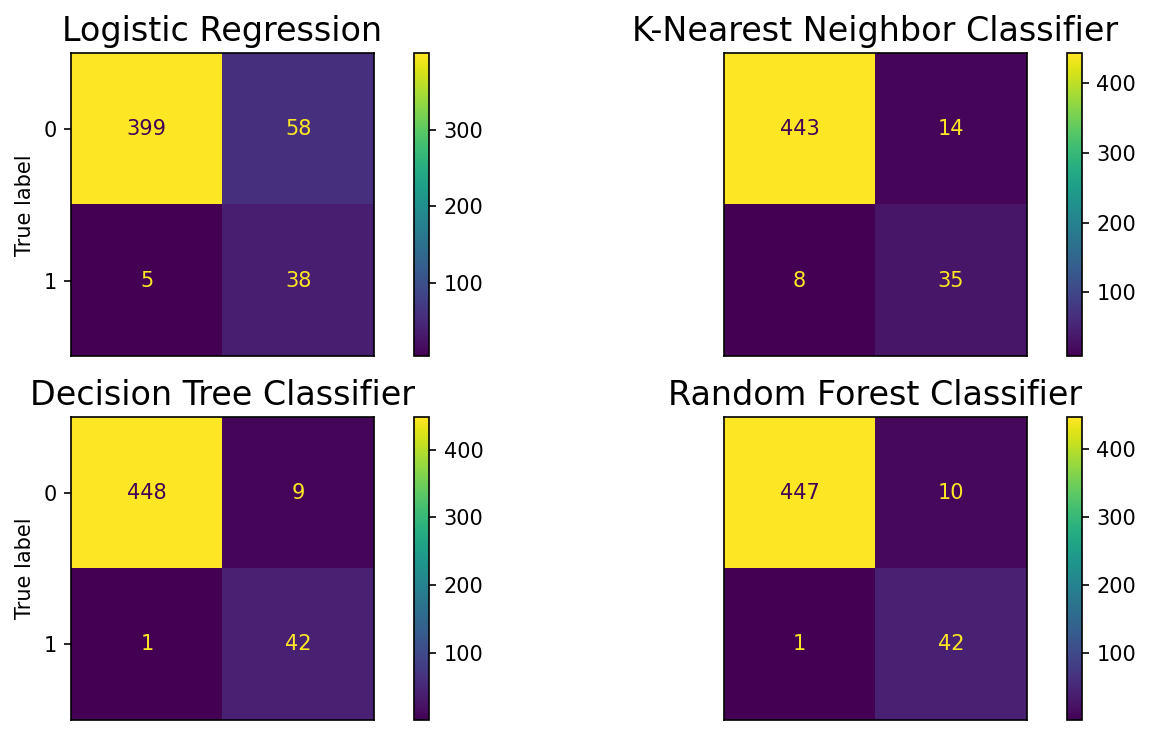

In [51]:
f, axes = plt.subplots(2, 2, figsize=(10,5),dpi=150)

axes[0, 0].set_title("Logistic Regression", size=16)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,log_model.predict(X_test_scaled)),display_labels=log_model.classes_).plot(ax=axes[0,0])
axes[0, 0].xaxis.set_ticklabels(['', ''])
axes[0, 0].set_xlabel('')
axes[0, 0].tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

axes[0, 1].set_title("K-Nearest Neighbor Classifier", size=16)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,knn_classifier.predict(X_test_scaled)),display_labels=knn_classifier.classes_).plot(ax=axes[0,1])
axes[0, 1].xaxis.set_ticklabels(['', ''])
axes[0, 1].yaxis.set_ticklabels(['', ''])
axes[0, 1].set_xlabel('')
axes[0, 1].set_ylabel('')
axes[0, 1].tick_params(axis='both', which='both', bottom=False, left=False)

axes[1, 0].set_title("Decision Tree Classifier", size=16)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,gs_dt_model.predict(X_test)),display_labels=gs_dt_model.classes_).plot(ax=axes[1,0])
axes[1, 0].xaxis.set_ticklabels(['', ''])
axes[1, 0].set_xlabel('')
axes[1, 0].tick_params(axis='x', which='both', bottom=False)


axes[1, 1].set_title("Random Forest Classifier", size=16)
ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test,gs_rfc_model.predict(X_test)),display_labels=gs_rfc_model.classes_).plot(ax=axes[1,1])
axes[1, 1].xaxis.set_ticklabels(['', ''])
axes[1, 1].yaxis.set_ticklabels(['', ''])
axes[1, 1].set_xlabel('')
axes[1, 1].set_ylabel('')
axes[1, 1].tick_params(axis='both', which='both', bottom=False, left=False)

plt.tight_layout();


In [53]:
from sklearn.metrics import roc_auc_score,roc_curve

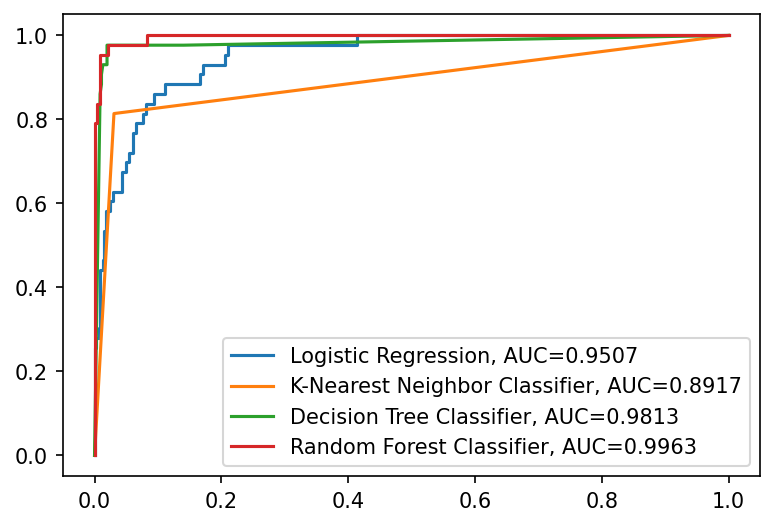

In [54]:
plt.figure(figsize=(6,4),dpi=150)

lgm_pred_prob = log_model.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, lgm_pred_prob)
auc = round(roc_auc_score(y_test, lgm_pred_prob), 4)
plt.plot(fpr,tpr,label="Logistic Regression, AUC="+str(auc))

knn_pred_prob = knn_classifier.predict_proba(X_test_scaled)[:,1]
fpr, tpr, _ = roc_curve(y_test, knn_pred_prob)
auc = round(roc_auc_score(y_test, knn_pred_prob), 4)
plt.plot(fpr,tpr,label="K-Nearest Neighbor Classifier, AUC="+str(auc))

dt_pred_prob = gs_dt_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, dt_pred_prob)
auc = round(roc_auc_score(y_test, dt_pred_prob), 4)
plt.plot(fpr,tpr,label="Decision Tree Classifier, AUC="+str(auc))

rfc_pred_prob = gs_rfc_model.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, rfc_pred_prob)
auc = round(roc_auc_score(y_test, rfc_pred_prob), 4)
plt.plot(fpr,tpr,label="Random Forest Classifier, AUC="+str(auc))

plt.legend();


In [55]:
from sklearn.metrics import PrecisionRecallDisplay,average_precision_score,precision_recall_curve

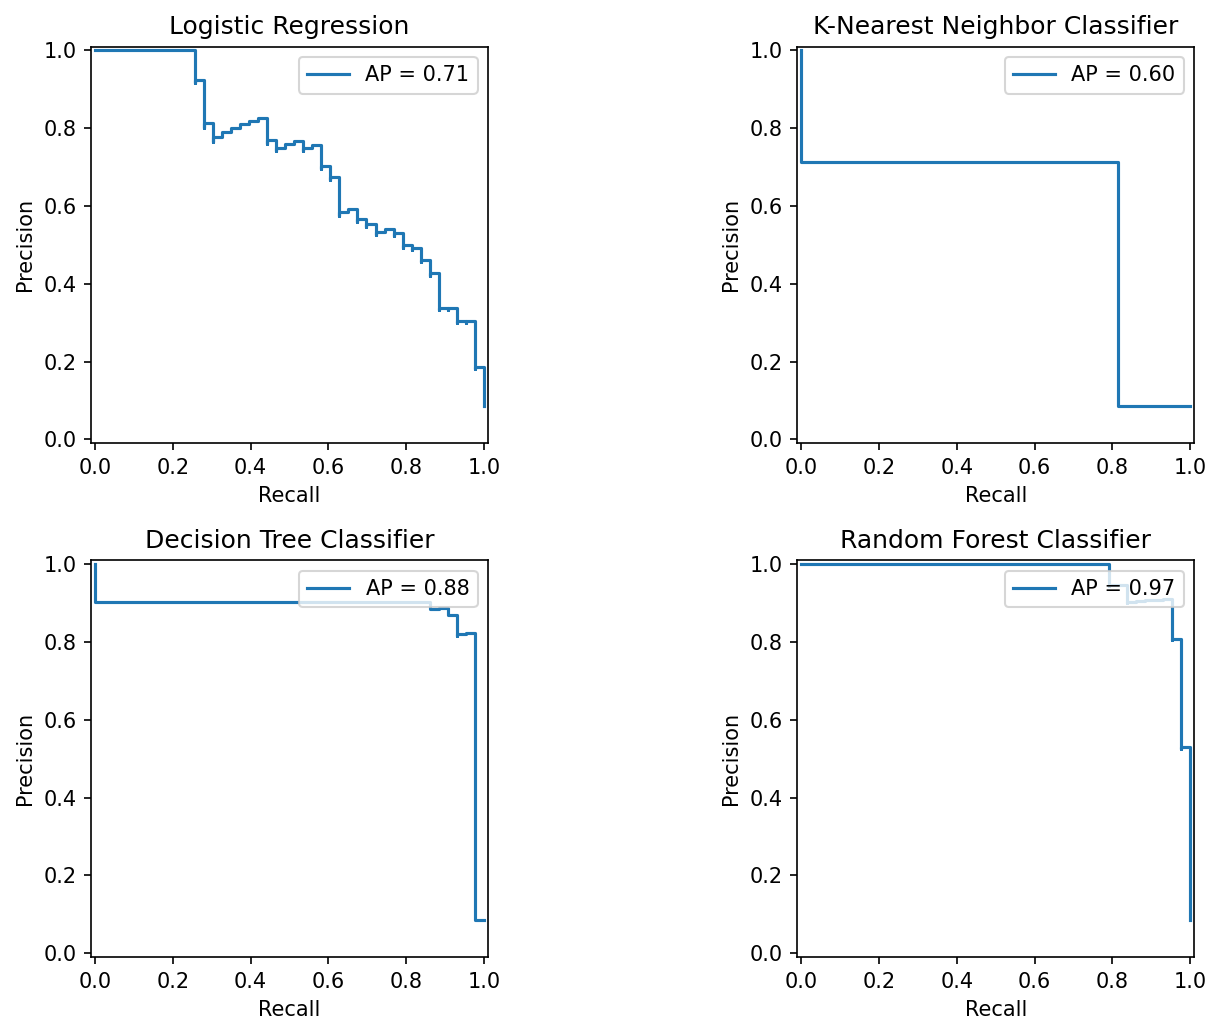

In [56]:
f, axes = plt.subplots(2, 2, figsize=(10,7),dpi=150)

axes[0, 0].set_title("Logistic Regression", size=12)
precision, recall, _ = precision_recall_curve(y_test, lgm_pred_prob)
ap = average_precision_score(y_test, lgm_pred_prob)
PrecisionRecallDisplay(precision, recall, average_precision=ap).plot(ax=axes[0,0])
axes[0,0].legend(loc='upper right')

axes[0, 1].set_title("K-Nearest Neighbor Classifier", size=12)
precision, recall, _ = precision_recall_curve(y_test, knn_pred_prob)
ap = average_precision_score(y_test, knn_pred_prob)
PrecisionRecallDisplay(precision, recall, average_precision=ap).plot(ax=axes[0,1])
axes[0,1].legend(loc='upper right')

axes[1, 0].set_title("Decision Tree Classifier", size=12)
precision, recall, _ = precision_recall_curve(y_test, dt_pred_prob)
ap = average_precision_score(y_test, dt_pred_prob)
PrecisionRecallDisplay(precision, recall, average_precision=ap).plot(ax=axes[1,0])
axes[1,0].legend(loc='upper right')

axes[1, 1].set_title("Random Forest Classifier", size=12)
precision, recall, _ = precision_recall_curve(y_test, rfc_pred_prob)
ap = average_precision_score(y_test, rfc_pred_prob)
PrecisionRecallDisplay(precision, recall, average_precision=ap).plot(ax=axes[1,1])
axes[1,1].legend(loc='upper right')

plt.tight_layout();